# Active-learning acquisition coverage

Plot the geometries available to each committee round on the complete HF grid. A round's training set is recorded in `acquired_before_indices`; points selected by that round therefore appear in the following round.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from ase.io import read

# This lets the notebook import project modules when launched from notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'sampling_methods').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sampling_methods import descriptors

# Change this if analysing a different active-learning run.
RESULT_PATH = PROJECT_ROOT / 'scripts/output/run_14/result.json'

with RESULT_PATH.open() as handle:
    result = json.load(handle)

config_path = PROJECT_ROOT / 'scripts/active-learning' / Path(result['input_file']).name
with config_path.open() as handle:
    config = json.load(handle)

hf_xyz = (config_path.parent / config['hf_xyz']).resolve()
hf_grid = read(hf_xyz, index=':')

coordinates = np.asarray([
    (
        descriptors.get_descriptor('bond_lengths', atoms)[0],
        descriptors.get_descriptor('dihedral', atoms)[0],
    )
    for atoms in hf_grid
])
cc_bond_lengths, hcch_dihedrals = coordinates.T

assert len(hf_grid) == result['hf_grid']['size']
print(f'Loaded {len(hf_grid)} grid geometries and {len(result["rounds"])} committee rounds.')

Loaded 3731 grid geometries and 3 committee rounds.


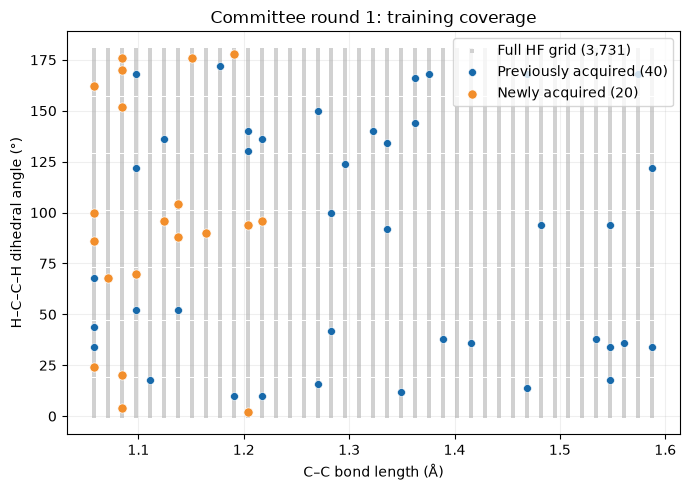

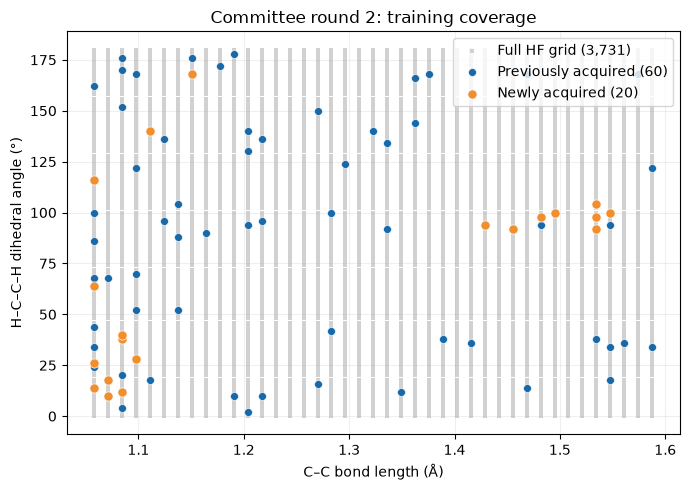

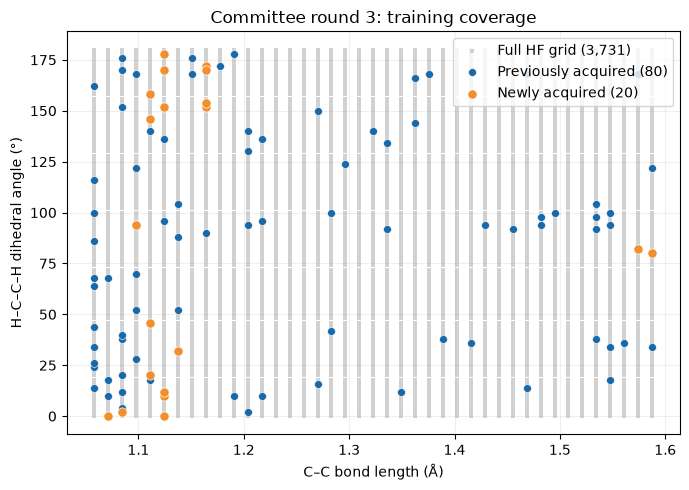

In [2]:
for round_record in result['rounds']:
    round_number = round_record['round_number'] + 1
    acquired = np.asarray(round_record['acquired_before_indices'], dtype=int)
    newly_acquired = np.asarray(
        round_record.get('selection', {}).get('acquired_indices', []), dtype=int
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        cc_bond_lengths, hcch_dihedrals,
        s=10, color='0.82', marker='s', linewidths=0,
        label=f'Full HF grid ({len(hf_grid):,})', zorder=1,
    )
    ax.scatter(
        cc_bond_lengths[acquired], hcch_dihedrals[acquired],
        s=32, color='#1769aa', edgecolor='white', linewidth=0.4,
        label=f'Previously acquired ({len(acquired):,})', zorder=2,
    )
    ax.scatter(
        cc_bond_lengths[newly_acquired], hcch_dihedrals[newly_acquired],
        s=44, color='#f28e2b', edgecolor='white', linewidth=0.5,
        label=f'Newly acquired ({len(newly_acquired):,})', zorder=3,
    )
    ax.set(
        title=f'Committee round {round_number}: training coverage',
        xlabel='C–C bond length (Å)',
        ylabel='H–C–C–H dihedral angle (°)',
    )
    ax.legend(loc='best')
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()


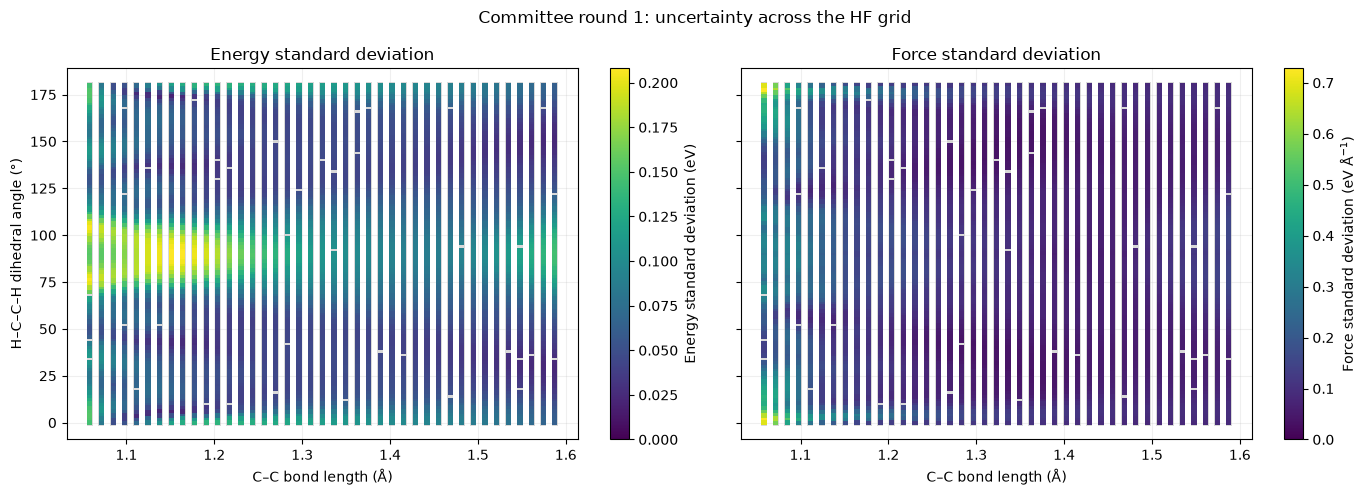

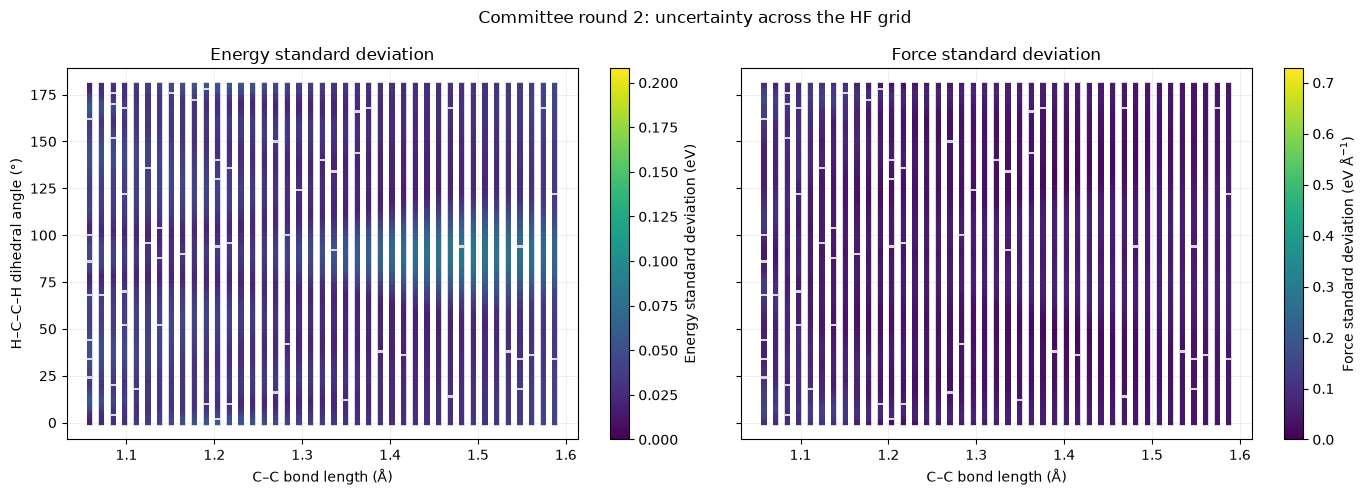

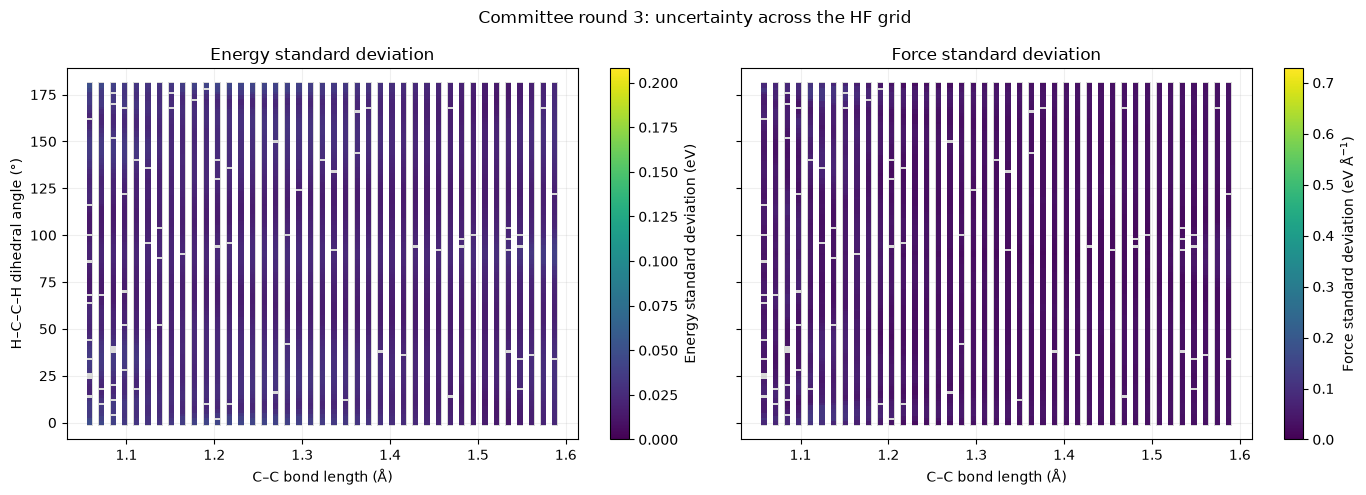

In [3]:
# Use common colour scales so uncertainty can be compared between rounds.
uncertainty_fields = {
    'energy_std': ('Energy standard deviation', 'eV'),
    'force_std': ('Force standard deviation', 'eV Å$^{-1}$'),
}
colour_limits = {
    field: (
        0.0,
        max(
            point[field]
            for round_record in result['rounds']
            for point in round_record['committee_uncertainty_by_index']
        ),
    )
    for field in uncertainty_fields
}

for round_record in result['rounds']:
    round_number = round_record['round_number'] + 1
    uncertainty_by_index = round_record['committee_uncertainty_by_index']
    indices = np.asarray([point['index'] for point in uncertainty_by_index], dtype=int)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    for ax, (field, (label, unit)) in zip(axes, uncertainty_fields.items()):
        values = np.asarray([point[field] for point in uncertainty_by_index])
        # Grey cells are already acquired, so they were not committee-evaluated this round.
        ax.scatter(
            cc_bond_lengths, hcch_dihedrals,
            s=14, color='0.85', marker='s', linewidths=0, zorder=1,
        )
        heatmap = ax.scatter(
            cc_bond_lengths[indices], hcch_dihedrals[indices], c=values,
            s=14, marker='s', linewidths=0, cmap='viridis',
            vmin=colour_limits[field][0], vmax=colour_limits[field][1], zorder=2,
        )
        colourbar = fig.colorbar(heatmap, ax=ax)
        colourbar.set_label(f'{label} ({unit})')
        ax.set(title=label, xlabel='C–C bond length (Å)')
        ax.grid(alpha=0.2)

    axes[0].set_ylabel('H–C–C–H dihedral angle (°)')
    fig.suptitle(f'Committee round {round_number}: uncertainty across the HF grid')
    fig.tight_layout()
    plt.show()


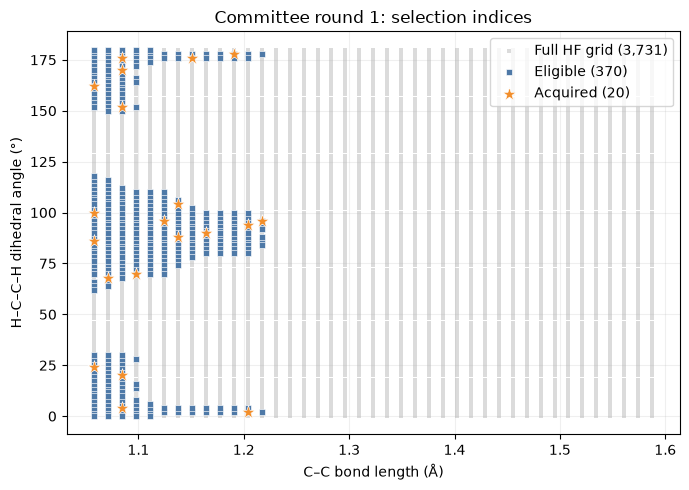

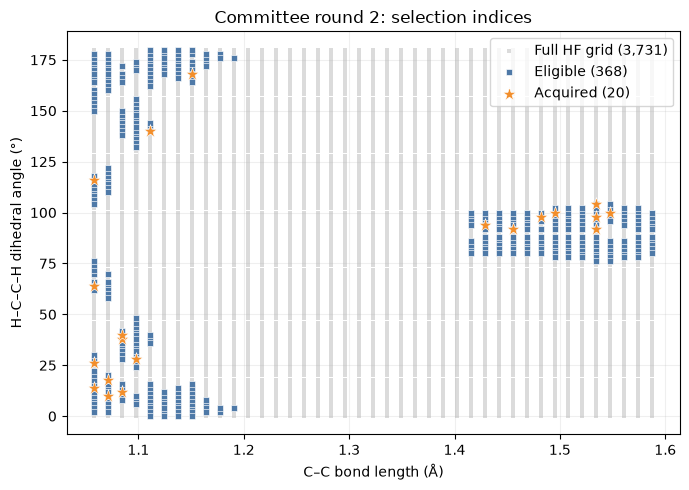

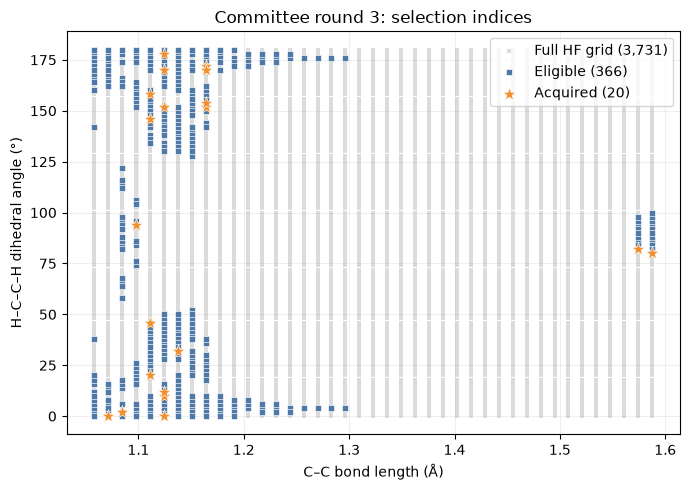

In [7]:
# Show the selection stages on the same HCCH-dihedral/bond-length grid.
selection_groups = (
    ('eligible_indices', 'Eligible', '#4e79a7', 's', 16),
    ('acquired_indices', 'Acquired', '#f28e2b', '*', 100),
)

for round_record in result['rounds']:
    round_number = round_record['round_number'] + 1
    selection = round_record.get('selection', {})

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        cc_bond_lengths, hcch_dihedrals,
        s=10, color='0.86', marker='s', linewidths=0,
        label=f'Full HF grid ({len(hf_grid):,})', zorder=1,
    )
    # Draw broad candidate sets first, then the selected subsets on top.
    for zorder, (key, label, colour, marker, size) in enumerate(selection_groups, start=2):
        indices = np.asarray(selection.get(key, []), dtype=int)
        if not len(indices):
            continue
        ax.scatter(
            cc_bond_lengths[indices], hcch_dihedrals[indices],
            s=size, color=colour, marker=marker, edgecolor='white', linewidth=0.45,
            label=f'{label} ({len(indices):,})', zorder=zorder,
        )

    ax.set(
        title=f'Committee round {round_number}: selection indices',
        xlabel='C–C bond length (Å)',
        ylabel='H–C–C–H dihedral angle (°)',
    )
    ax.legend(loc='best')
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()


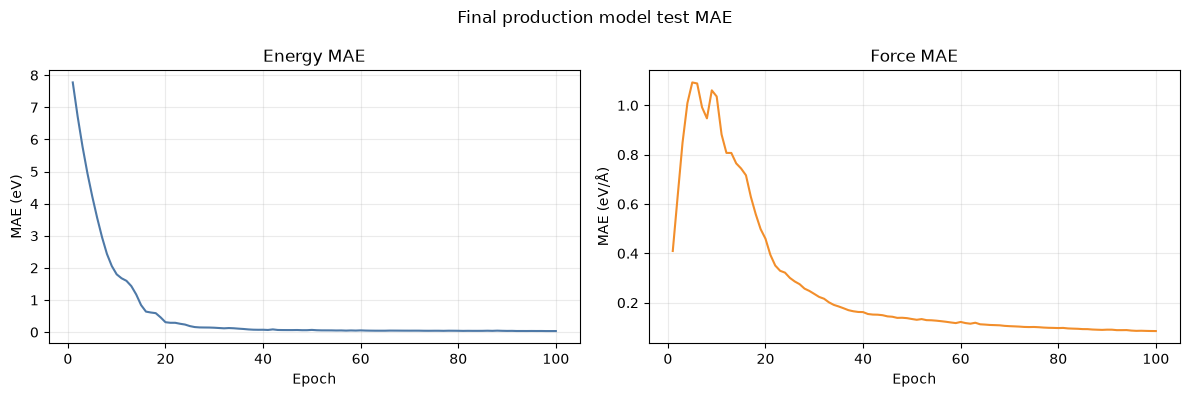

In [9]:
# Plot the final production model's training MAEs from the active-learning result.
production_history = result['final_production_model']['history']
epochs = production_history['epoch']

fig, (energy_ax, force_ax) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
energy_ax.plot(epochs, production_history['train_energy_mae'], color='#4e79a7')
force_ax.plot(epochs, production_history['train_force_mae'], color='#f28e2b')

energy_ax.set(
    title='Energy MAE', xlabel='Epoch', ylabel='MAE (eV)',
)
force_ax.set(
    title='Force MAE', xlabel='Epoch', ylabel='MAE (eV/Å)',
)
for ax in (energy_ax, force_ax):
    ax.grid(alpha=0.25)

fig.suptitle('Final production model test MAE')
fig.tight_layout()
plt.show()
